# 02 电商行为漏斗分析

## 本 notebook 目标

本 notebook 用于分析用户从浏览、加购到购买的行为路径，并构建电商转化漏斗。

需要特别区分三种口径：

1. **独立行为统计**  
   分别统计发生过 view、cart、purchase 的用户数，不要求行为顺序。

2. **用户级严格序列漏斗**  
   要求用户在整个观察期内满足 view → cart → purchase 的时间顺序，允许跨天完成转化。

3. **每日用户级严格序列漏斗**  
   要求用户在同一自然日内完成 view → cart → purchase，用于观察日内转化效率。

这一部分的结论会为后续特征工程提供业务依据。

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

os.makedirs("../outputs/tables", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

clean_data_path = "../data/processed/ecommerce_behavior_2019_10_01_15_clean.csv"

df = pd.read_csv(clean_data_path)

core_events = ["view", "cart", "purchase"]
df = df[df["event_type"].isin(core_events)].copy()

In [2]:
# 1. 独立行为用户数统计
# 该部分分别统计发生过 view、cart、purchase 的用户数,独立行为统计不要求用户行为满足 view -> cart -> purchase 的顺序。
independent_funnel = (
    df.groupby("event_type")["user_id"]
    .nunique()
    .reindex(core_events)
    .reset_index()
)

independent_funnel.columns = ["event_type", "user_count"]

view_users = independent_funnel.loc[
    independent_funnel["event_type"] == "view",
    "user_count"
].iloc[0]

independent_funnel["ratio_to_view_users"] = (
    independent_funnel["user_count"] / view_users
)

display(independent_funnel)

independent_funnel.to_csv(
    "../outputs/tables/independent_funnel_user_count.csv",
    index=False,
    encoding="utf-8-sig"
)

,event_type,user_count,ratio_to_view_users
0,view,1781733,1.000000
1,cart,158286,0.088838
2,purchase,186997,0.104952


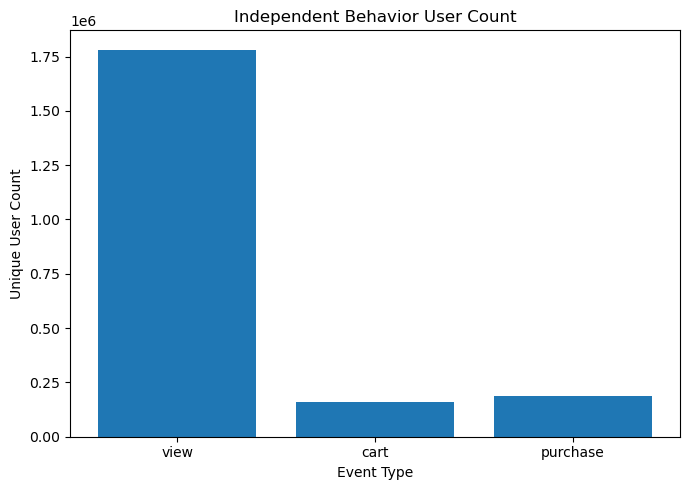

In [3]:
# 2. 独立行为用户数图
plt.figure(figsize=(7, 5))

plt.bar(
    independent_funnel["event_type"],
    independent_funnel["user_count"]
)

plt.title("Independent Behavior User Count")
plt.xlabel("Event Type")
plt.ylabel("Unique User Count")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/independent_funnel_user_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [4]:
# 3. 用户级严格序列漏斗
# 定义：
# step1: 用户发生过 view
# step2: 用户在 view 之后发生过 cart
# step3: 用户在 cart 之后发生过 purchase
def build_user_level_sequential_funnel(data):
    
    data = data.sort_values(["user_id", "event_time"]).copy()

    first_view = (
        data[data["event_type"] == "view"]
        .groupby("user_id")["event_time"]
        .min()
        .reset_index(name="first_view_time")
    )

    cart_after_view = data.merge(
        first_view,
        on="user_id",
        how="inner"
    )

    cart_after_view = cart_after_view[
        (cart_after_view["event_type"] == "cart") &
        (cart_after_view["event_time"] > cart_after_view["first_view_time"])
    ]

    first_cart_after_view = (
        cart_after_view
        .groupby("user_id")["event_time"]
        .min()
        .reset_index(name="first_cart_after_view_time")
    )

    purchase_after_cart = data.merge(
        first_cart_after_view,
        on="user_id",
        how="inner"
    )

    purchase_after_cart = purchase_after_cart[
        (purchase_after_cart["event_type"] == "purchase") &
        (purchase_after_cart["event_time"] > purchase_after_cart["first_cart_after_view_time"])
    ]

    first_purchase_after_cart = (
        purchase_after_cart
        .groupby("user_id")["event_time"]
        .min()
        .reset_index(name="first_purchase_after_cart_time")
    )

    view_user_count = first_view["user_id"].nunique()
    cart_after_view_user_count = first_cart_after_view["user_id"].nunique()
    purchase_after_cart_user_count = first_purchase_after_cart["user_id"].nunique()

    funnel = pd.DataFrame({
        "funnel_step": ["view", "cart_after_view", "purchase_after_cart"],
        "user_count": [
            view_user_count,
            cart_after_view_user_count,
            purchase_after_cart_user_count
        ]
    })

    funnel["step_conversion_rate"] = [
        np.nan,
        cart_after_view_user_count / view_user_count if view_user_count > 0 else np.nan,
        purchase_after_cart_user_count / cart_after_view_user_count if cart_after_view_user_count > 0 else np.nan
    ]

    funnel["overall_conversion_rate"] = (
        funnel["user_count"] / view_user_count
        if view_user_count > 0
        else np.nan
    )

    return funnel

In [5]:
user_level_sequential_funnel = build_user_level_sequential_funnel(df)

display(user_level_sequential_funnel)

user_level_sequential_funnel.to_csv(
    "../outputs/tables/user_level_sequential_funnel.csv",
    index=False,
    encoding="utf-8-sig"
)

,funnel_step,user_count,step_conversion_rate,overall_conversion_rate
0,view,1781733,NaN,1.000000
1,cart_after_view,158096,0.088732,0.088732
2,purchase_after_cart,91951,0.581615,0.051608


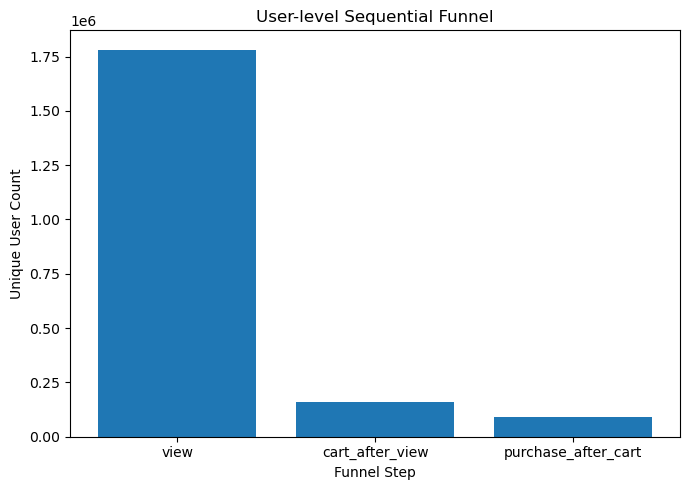

In [6]:
# 4. 用户级严格序列漏斗图
plt.figure(figsize=(7, 5))

plt.bar(
    user_level_sequential_funnel["funnel_step"],
    user_level_sequential_funnel["user_count"]
)

plt.title("User-level Sequential Funnel")
plt.xlabel("Funnel Step")
plt.ylabel("Unique User Count")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/user_level_sequential_funnel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
# 5. Session 级严格序列漏斗
# Session 级漏斗要求同一个 user_session 内满足 view -> cart -> purchase。
def build_session_level_sequential_funnel(data):
    
    session_data = data.dropna(subset=["user_session"]).copy()
    session_data = session_data.sort_values(["user_session", "event_time"])

    first_view = (
        session_data[session_data["event_type"] == "view"]
        .groupby("user_session")["event_time"]
        .min()
        .reset_index(name="first_view_time")
    )

    cart_after_view = session_data.merge(
        first_view,
        on="user_session",
        how="inner"
    )

    cart_after_view = cart_after_view[
        (cart_after_view["event_type"] == "cart") &
        (cart_after_view["event_time"] > cart_after_view["first_view_time"])
    ]

    first_cart_after_view = (
        cart_after_view
        .groupby("user_session")["event_time"]
        .min()
        .reset_index(name="first_cart_after_view_time")
    )

    purchase_after_cart = session_data.merge(
        first_cart_after_view,
        on="user_session",
        how="inner"
    )

    purchase_after_cart = purchase_after_cart[
        (purchase_after_cart["event_type"] == "purchase") &
        (purchase_after_cart["event_time"] > purchase_after_cart["first_cart_after_view_time"])
    ]

    first_purchase_after_cart = (
        purchase_after_cart
        .groupby("user_session")["event_time"]
        .min()
        .reset_index(name="first_purchase_after_cart_time")
    )

    view_session_count = first_view["user_session"].nunique()
    cart_session_count = first_cart_after_view["user_session"].nunique()
    purchase_session_count = first_purchase_after_cart["user_session"].nunique()

    funnel = pd.DataFrame({
        "funnel_step": ["view", "cart_after_view", "purchase_after_cart"],
        "session_count": [
            view_session_count,
            cart_session_count,
            purchase_session_count
        ]
    })

    funnel["step_conversion_rate"] = [
        np.nan,
        cart_session_count / view_session_count if view_session_count > 0 else np.nan,
        purchase_session_count / cart_session_count if cart_session_count > 0 else np.nan
    ]

    funnel["overall_conversion_rate"] = (
        funnel["session_count"] / view_session_count
        if view_session_count > 0
        else np.nan
    )

    return funnel

In [8]:
session_level_sequential_funnel = build_session_level_sequential_funnel(df)

display(session_level_sequential_funnel)

session_level_sequential_funnel.to_csv(
    "../outputs/tables/session_level_sequential_funnel.csv",
    index=False,
    encoding="utf-8-sig"
)

,funnel_step,session_count,step_conversion_rate,overall_conversion_rate
0,view,4382818,NaN,1.000000
1,cart_after_view,242745,0.055386,0.055386
2,purchase_after_cart,123376,0.508254,0.028150


In [9]:
# 6. 每日独立行为漏斗
# 该部分统计每天发生过 view/cart/purchase 的用户数,不要求行为顺序
daily_independent_funnel = (
    df.groupby(["date", "event_type"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
    .reset_index()
)

for event in core_events:
    if event not in daily_independent_funnel.columns:
        daily_independent_funnel[event] = 0

daily_independent_funnel["cart_user_rate"] = np.where(
    daily_independent_funnel["view"] > 0,
    daily_independent_funnel["cart"] / daily_independent_funnel["view"],
    np.nan
)

daily_independent_funnel["purchase_user_rate"] = np.where(
    daily_independent_funnel["view"] > 0,
    daily_independent_funnel["purchase"] / daily_independent_funnel["view"],
    np.nan
)

display(daily_independent_funnel.head())

daily_independent_funnel.to_csv(
    "../outputs/tables/daily_independent_funnel.csv",
    index=False,
    encoding="utf-8-sig"
)

event_type,date,cart,purchase,view,cart_user_rate,purchase_user_rate
0,2019-10-01,8771,14064,190158,0.046125,0.073960
1,2019-10-02,8862,13894,184955,0.047914,0.075121
2,2019-10-03,9793,13722,170655,0.057385,0.080408
3,2019-10-04,21714,19214,209393,0.103700,0.091760
4,2019-10-05,17457,16734,194949,0.089546,0.085838


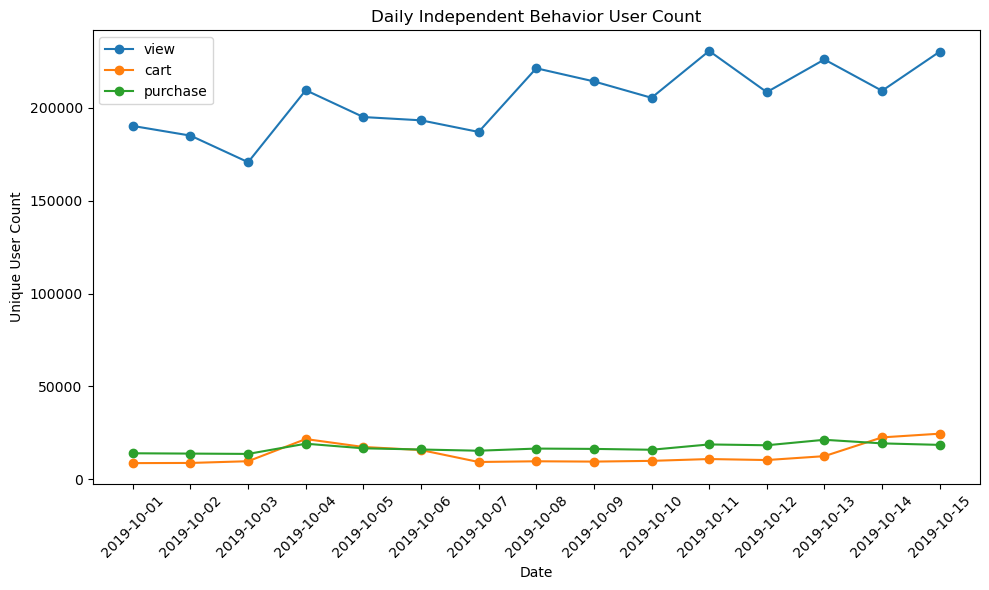

In [10]:
# 7. 每日独立行为用户数趋势图
plt.figure(figsize=(10, 6))

for event in core_events:
    plt.plot(
        daily_independent_funnel["date"],
        daily_independent_funnel[event],
        marker="o",
        label=event
    )

plt.title("Daily Independent Behavior User Count")
plt.xlabel("Date")
plt.ylabel("Unique User Count")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/daily_independent_behavior_user_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
# 8. 每日用户级严格序列漏斗
# 要求用户在同一自然日内完成 view -> cart -> purchase。
daily_seq_records = []

for current_date, temp_df in df.groupby("date"):
    temp_funnel = build_user_level_sequential_funnel(temp_df)

    view_users = temp_funnel.loc[
        temp_funnel["funnel_step"] == "view",
        "user_count"
    ].iloc[0]

    cart_after_view_users = temp_funnel.loc[
        temp_funnel["funnel_step"] == "cart_after_view",
        "user_count"
    ].iloc[0]

    purchase_after_cart_users = temp_funnel.loc[
        temp_funnel["funnel_step"] == "purchase_after_cart",
        "user_count"
    ].iloc[0]

    daily_seq_records.append({
        "date": current_date,
        "view_users": view_users,
        "cart_after_view_users": cart_after_view_users,
        "purchase_after_cart_users": purchase_after_cart_users,
        "view_to_cart_rate": cart_after_view_users / view_users if view_users > 0 else np.nan,
        "cart_to_purchase_rate": purchase_after_cart_users / cart_after_view_users if cart_after_view_users > 0 else np.nan,
        "view_to_purchase_rate": purchase_after_cart_users / view_users if view_users > 0 else np.nan
    })

daily_user_level_sequential_funnel = pd.DataFrame(daily_seq_records)

display(daily_user_level_sequential_funnel.head())

daily_user_level_sequential_funnel.to_csv(
    "../outputs/tables/daily_user_level_sequential_funnel.csv",
    index=False,
    encoding="utf-8-sig"
)

,date,view_users,cart_after_view_users,purchase_after_cart_users,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,2019-10-01,190158,8757,5229,0.046051,0.597122,0.027498
1,2019-10-02,184955,8851,5352,0.047855,0.604677,0.028937
2,2019-10-03,170655,9770,5690,0.057250,0.582395,0.033342
3,2019-10-04,209393,21664,11030,0.103461,0.509140,0.052676
4,2019-10-05,194949,17411,9220,0.089311,0.529550,0.047294


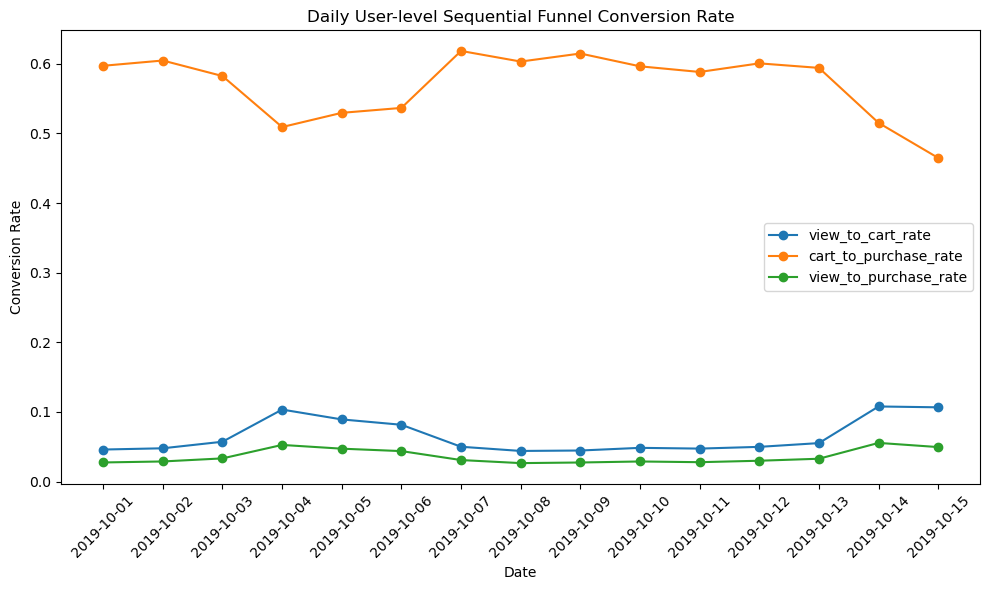

In [12]:
# 9. 每日严格序列漏斗转化率图
plt.figure(figsize=(10, 6))

plt.plot(
    daily_user_level_sequential_funnel["date"],
    daily_user_level_sequential_funnel["view_to_cart_rate"],
    marker="o",
    label="view_to_cart_rate"
)

plt.plot(
    daily_user_level_sequential_funnel["date"],
    daily_user_level_sequential_funnel["cart_to_purchase_rate"],
    marker="o",
    label="cart_to_purchase_rate"
)

plt.plot(
    daily_user_level_sequential_funnel["date"],
    daily_user_level_sequential_funnel["view_to_purchase_rate"],
    marker="o",
    label="view_to_purchase_rate"
)

plt.title("Daily User-level Sequential Funnel Conversion Rate")
plt.xlabel("Date")
plt.ylabel("Conversion Rate")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/daily_user_level_sequential_funnel_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 本节小结

1. 独立行为统计用于观察 view/cart/purchase 的用户规模，但不能直接解释为严格漏斗。
2. 用户级严格序列漏斗要求行为满足 view -> cart -> purchase 的时间顺序，允许跨天完成。
3. Session 级严格序列漏斗要求在同一个 session 内完成完整路径，口径更严格。
4. 每日严格序列漏斗反映的是同一自然日内的转化效率。
5. 从漏斗结果看，view -> cart 是主要流失环节，而 cart -> purchase 转化率相对较高。
6. 因此，cart 相关特征是后续购买预测中的重要行为信号。